In [1]:
import pandas, numpy

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

In [3]:
single_file = '/Users/adrian/research/bmcbf/044_blaskogar/results/single/GSM4632638_processed/kallisto_output_a/abundance.tsv'
paired_file = '/Users/adrian/research/bmcbf/044_blaskogar/results/quantification/GSM4632638_processed/kallisto_output_a/abundance.tsv'

In [4]:
dfs = pandas.read_csv(single_file, sep='\t')
dfs

,target_id,length,eff_length,est_counts,tpm
0,ENST00000308647.8,2114,1935.0,95.4813,1.690190
1,ENST00000378736.3,414,235.0,20.9212,3.049420
2,ENST00000472194.6,4314,4135.0,231.8810,1.920830
3,ENST00000474481.1,3367,3188.0,98.2876,1.056040
4,ENST00000485748.5,3233,3054.0,103.5780,1.161710
...,...,...,...,...,...
227660,ENST00000619729.1,294,115.0,0.0000,0.000000
227661,ENST00000612640.4,2116,1937.0,274.1600,4.848120
227662,ENST00000614336.4,3728,3549.0,795.9540,7.682120
227663,ENST00000601199.2,510,331.0,0.0000,0.000000


In [5]:
dfp = pandas.read_csv(paired_file, sep='\t')
dfp

,target_id,length,eff_length,est_counts,tpm
0,ENST00000308647.8,2114,1893.800,33.8040,1.217580
1,ENST00000378736.3,414,202.524,13.3288,4.489320
2,ENST00000472194.6,4314,4093.800,111.9400,1.865190
3,ENST00000474481.1,3367,3146.800,47.9323,1.039020
4,ENST00000485748.5,3233,3012.800,38.3151,0.867487
...,...,...,...,...,...
227660,ENST00000619729.1,294,103.450,0.0000,0.000000
227661,ENST00000612640.4,2116,1895.800,154.0130,5.541530
227662,ENST00000614336.4,3728,3507.800,253.3510,4.926650
227663,ENST00000601199.2,510,292.626,0.0000,0.000000


In [6]:
epsilon = 1
x = numpy.log10(dfp['tpm']+epsilon)
y = numpy.log2(dfs['tpm']+epsilon) - numpy.log2(dfp['tpm']+epsilon)

In [11]:
redindexes = numpy.where((x > numpy.log10(3+1)) & (y >= 1))[0]
blueindexes = numpy.where((x > numpy.log10(3+1)) & (y <= -1))[0]
blackindexes = numpy.where((x > numpy.log10(3+1)) & (-1 < y) & (y < 1))[0]

print(len(redindexes), len(blueindexes), len(blackindexes))
print(100*(309+513)/20442)
print(20000*(309+513)/20442)
print(sum([309, 513, 20442]))

309 513 20442
4.021132961549751
804.2265923099501
21264


In [8]:
numpy.log2(1/11)

-3.4594316186372973

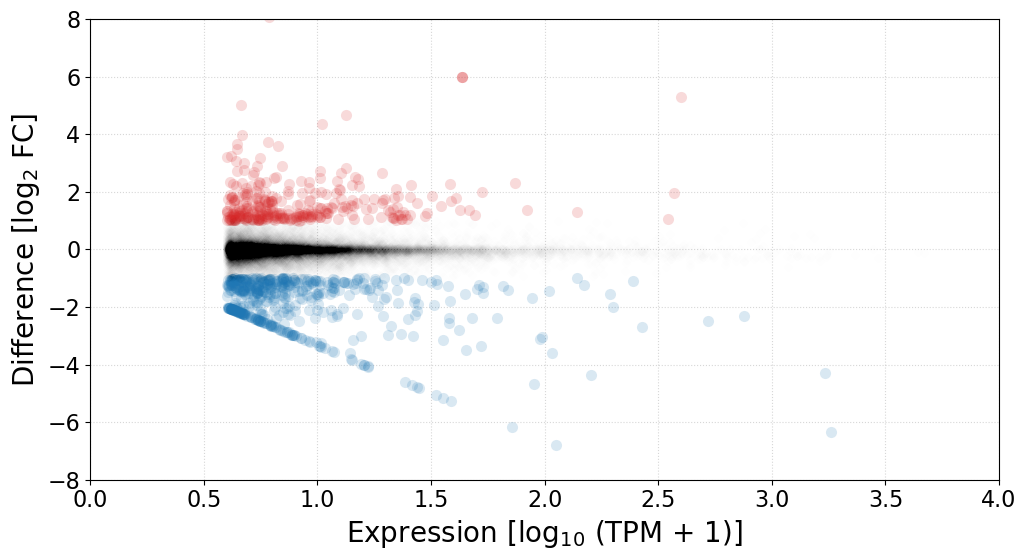

In [9]:
matplotlib.pyplot.plot(x[redindexes], y[redindexes], 'o', color='tab:red', alpha=1/6, mec='none', ms=8)
matplotlib.pyplot.plot(x[blueindexes], y[blueindexes], 'o', color='tab:blue', alpha=1/6, mec='none', ms=8)
matplotlib.pyplot.plot(x[blackindexes], y[blackindexes], 'o', color='black', alpha=1/500, mec='none', ms=6)

matplotlib.pyplot.xlim(0, 4)
matplotlib.pyplot.ylim(-8, 8)

matplotlib.pyplot.xlabel('Expression [log$_{10}$ (TPM + 1)]')
matplotlib.pyplot.ylabel('Difference [log$_{2}$ FC]')


matplotlib.pyplot.grid(alpha=0.5, ls=':')
matplotlib.pyplot.tight_layout()

matplotlib.pyplot.show()